# Lesson 3
## Classification

In [39]:
import sklearn 
from sklearn.linear_model import LinearRegression
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error
import pandas as pd
import numpy as np
import matplotlib.pylab as plt
import seaborn as sns

## Part(a)
### Load the Data (Real Data)

In [40]:
df=sns.load_dataset('iris')
df.head()

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa


In [56]:
newdf1=df[df["species"]=="setosa"].sample(n=3,random_state=42)
newdf2=df[df["species"]=="versicolor"].sample(n=3,random_state=42)
newdf3=df[df["species"]=="virginica"].sample(n=3,random_state=42)
newdf=pd.concat([newdf1,newdf2,newdf3])
newdf

,sepal_length,sepal_width,petal_length,petal_width,species
13,4.3,3.0,1.1,0.1,setosa
39,5.1,3.4,1.5,0.2,setosa
30,4.8,3.1,1.6,0.2,setosa
63,6.1,2.9,4.7,1.4,versicolor
89,5.5,2.5,4.0,1.3,versicolor
80,5.5,2.4,3.8,1.1,versicolor
113,5.7,2.5,5.0,2.0,virginica
139,6.9,3.1,5.4,2.1,virginica
130,7.4,2.8,6.1,1.9,virginica


## Part (b)
### Visualize the Data

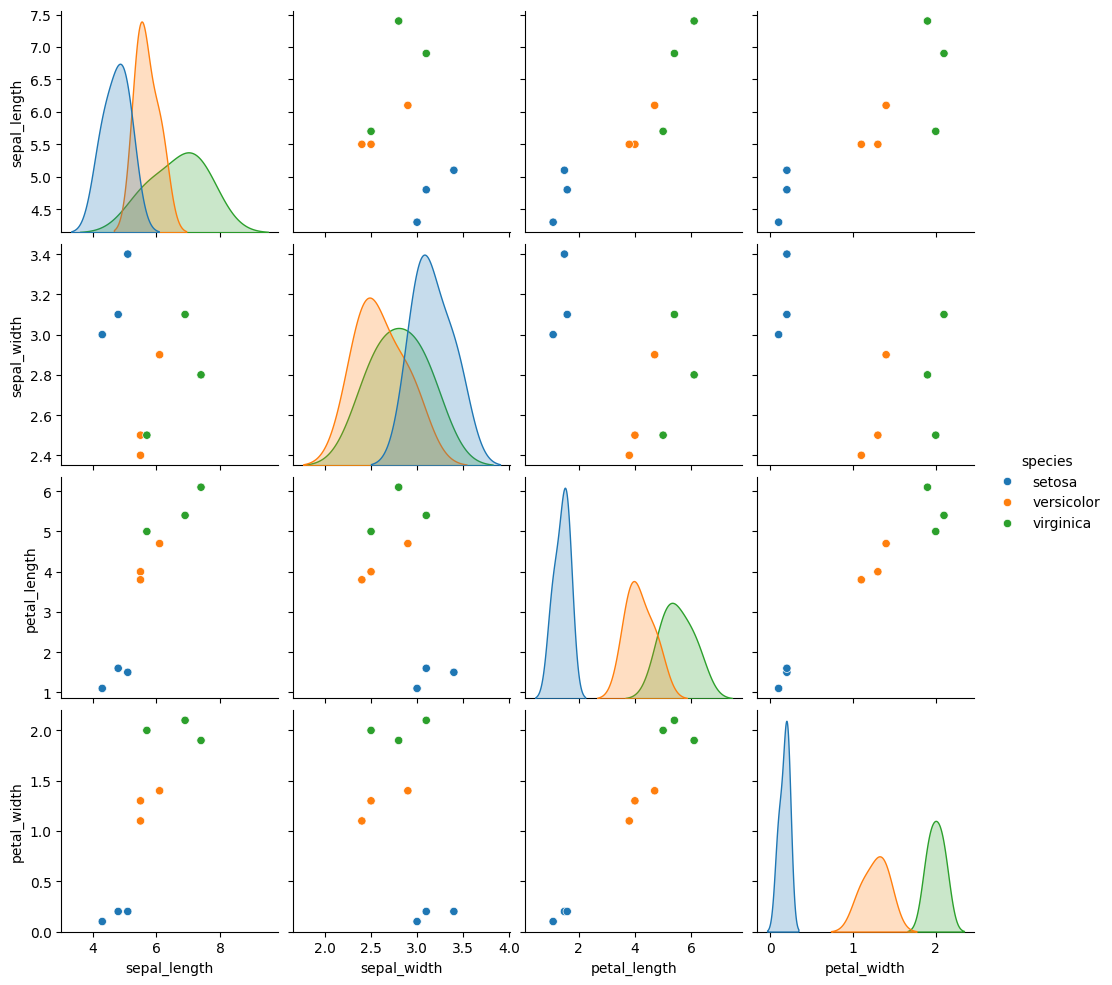

In [57]:
sns.pairplot(data=newdf,hue='species')
plt.show()

## Part (c)
### Preparing the Data (X, y, and Split)

In [43]:
X=df.drop('species',axis=1)
y=df['species']

In [44]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [45]:
X_train

,sepal_length,sepal_width,petal_length,petal_width
22,4.6,3.6,1.0,0.2
15,5.7,4.4,1.5,0.4
65,6.7,3.1,4.4,1.4
11,4.8,3.4,1.6,0.2
42,4.4,3.2,1.3,0.2
...,...,...,...,...
71,6.1,2.8,4.0,1.3
106,4.9,2.5,4.5,1.7
14,5.8,4.0,1.2,0.2
92,5.8,2.6,4.0,1.2


## Part (d)

In [46]:
model=LogisticRegression(max_iter=1000)
model.fit(X_train,y_train)
prediction=model.predict(X_test)
prediction

array(['versicolor', 'setosa', 'virginica', 'versicolor', 'versicolor',
       'setosa', 'versicolor', 'virginica', 'versicolor', 'versicolor',
       'virginica', 'setosa', 'setosa', 'setosa', 'setosa', 'versicolor',
       'virginica', 'versicolor', 'versicolor', 'virginica', 'setosa',
       'virginica', 'setosa', 'virginica', 'virginica', 'virginica',
       'virginica', 'virginica', 'setosa', 'setosa'], dtype=object)

In [47]:
comparsion=pd.DataFrame({
    'Test content': X_test.astype(str).agg(' | '.join, axis=1),
    'y_test':y_test.values,
    'Model Prediction':prediction,
})
comparsion.head()

,Test content,y_test,Model Prediction
73,6.1 | 2.8 | 4.7 | 1.2,versicolor,versicolor
18,5.7 | 3.8 | 1.7 | 0.3,setosa,setosa
118,7.7 | 2.6 | 6.9 | 2.3,virginica,virginica
78,6.0 | 2.9 | 4.5 | 1.5,versicolor,versicolor
76,6.8 | 2.8 | 4.8 | 1.4,versicolor,versicolor


In [48]:
from sklearn.metrics import accuracy_score
accuracy = accuracy_score(y_test, prediction)
accuracy


1.0

## Part (e)

In [49]:
'''
new_flower = [[5.1, 3.5, 1.4, 0.2]]
pr=model.predict(new_flower)
pr
'''

'\nnew_flower = [[5.1, 3.5, 1.4, 0.2]]\npr=model.predict(new_flower)\npr\n'

## Part (f)

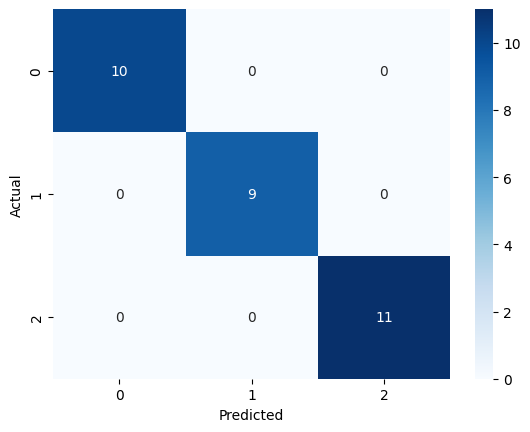

In [50]:
from sklearn.metrics import confusion_matrix
cm=confusion_matrix(y_test,prediction)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()